In [1]:
from pathlib import Path
import numpy as np
import torch
from PIL import Image
import json

LOCATION = "montesansalvatore"  # cambia con il nome della tua cartella

DATASET_DIR = Path("foto") / LOCATION
OUTPUT_DIR = Path("output") / LOCATION
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Device: {device}")
print(f"Foto in: {DATASET_DIR}")
print(f"Output in: {OUTPUT_DIR}")

Device: mps
Foto in: foto/montesansalvatore
Output in: output/montesansalvatore


In [2]:
# Trova tutte le immagini .jpg
image_paths = sorted(DATASET_DIR.glob("*.jpg"))

# Aggiungi varianti di estensione (case-insensitive)
image_paths += sorted(DATASET_DIR.glob("*.JPG"))
image_paths += sorted(DATASET_DIR.glob("*.jpeg"))

# Rimuovi duplicati e ordina
image_paths = sorted(set(image_paths))

print(f"Trovate {len(image_paths)} immagini")
print(f"\nPrime 5:")
for p in image_paths[:5]:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name} ({size_kb:.0f} KB)")

print(f"\nUltime 5:")
for p in image_paths[-5:]:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name} ({size_kb:.0f} KB)")

Trovate 1955 immagini

Prime 5:
  2770006052601813637_01.jpg (180 KB)
  2770783753799895289_01.jpg (495 KB)
  2770820337215549131_01.jpg (584 KB)
  2772022845355177290_01.jpg (769 KB)
  2772832518900254283_01.jpg (268 KB)

Ultime 5:
  3820672644912256288_01.jpg (121 KB)
  3821012833887080718_01.jpg (742 KB)
  3821547207552412318_01.jpg (345 KB)
  3823599554369794488_01.jpg (101 KB)
  3825260727813126097_01.jpg (83 KB)


In [3]:
from transformers import AutoImageProcessor, AutoModel

model_name = "facebook/dinov2-large"

print(f"Caricamento {model_name}...")
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

print("Modello DINOv2 ViT-L caricato!")
print(f"Device: {device}")

Caricamento facebook/dinov2-large...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Modello DINOv2 ViT-L caricato!
Device: mps


In [4]:
from tqdm.notebook import tqdm
from sklearn.preprocessing import normalize

embeddings = []
valid_paths = []
errors = []

with torch.no_grad():
    for path in tqdm(image_paths, desc="Estrazione embedding DINOv2"):
        try:
            image = Image.open(path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            features = model(**inputs)
            emb = features.pooler_output.cpu().numpy()[0]
            embeddings.append(emb)
            valid_paths.append(path)
        except Exception as e:
            errors.append((path.name, str(e)))

embeddings = np.array(embeddings)
embeddings_normalized = normalize(embeddings)

print(f"\nEmbedding estratti: {embeddings.shape}")
print(f"Errori: {len(errors)}")

np.save(OUTPUT_DIR / "embeddings_dinov2.npy", embeddings_normalized)
paths_str = [str(p) for p in valid_paths]
with open(OUTPUT_DIR / "paths_dinov2.json", "w") as f:
    json.dump(paths_str, f, indent=2)

print(f"Salvati in {OUTPUT_DIR}")

Estrazione embedding DINOv2:   0%|          | 0/1955 [00:00<?, ?it/s]


Embedding estratti: (1955, 1024)
Errori: 0
Salvati in output/montesansalvatore


In [46]:
import hdbscan
from collections import Counter

labels = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom'
).fit_predict(embeddings_normalized)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== RISULTATI DINOv2 ===")
print(f"Cluster identificati: {n_clusters}")
print(f"Foto in cluster: {len(labels) - n_noise} ({100*(len(labels) - n_noise)/len(labels):.1f}%)")
print(f"Foto rumore: {n_noise} ({100*n_noise/len(labels):.1f}%)")

print(f"\n=== TUTTI I CLUSTER ===")
counter = Counter(labels)
for cluster_id, count in sorted(counter.items(), key=lambda x: -x[1]):
    if cluster_id == -1:
        continue
    print(f"Cluster {cluster_id:3d}: {count:4d} foto")

cluster_ordinati = [c for c, _ in sorted(counter.items(), key=lambda x: -x[1]) if c != -1]


=== RISULTATI DINOv2 ===
Cluster identificati: 18
Foto in cluster: 443 (39.5%)
Foto rumore: 678 (60.5%)

=== TUTTI I CLUSTER ===
Cluster  14:  158 foto
Cluster  16:   79 foto
Cluster   9:   34 foto
Cluster  13:   19 foto
Cluster   3:   18 foto
Cluster   0:   17 foto
Cluster  12:   16 foto
Cluster  17:   15 foto
Cluster   8:   13 foto
Cluster  11:   13 foto
Cluster   1:   11 foto
Cluster   6:   10 foto
Cluster   5:    9 foto
Cluster  10:    7 foto
Cluster   4:    6 foto
Cluster  15:    6 foto
Cluster   7:    6 foto
Cluster   2:    6 foto


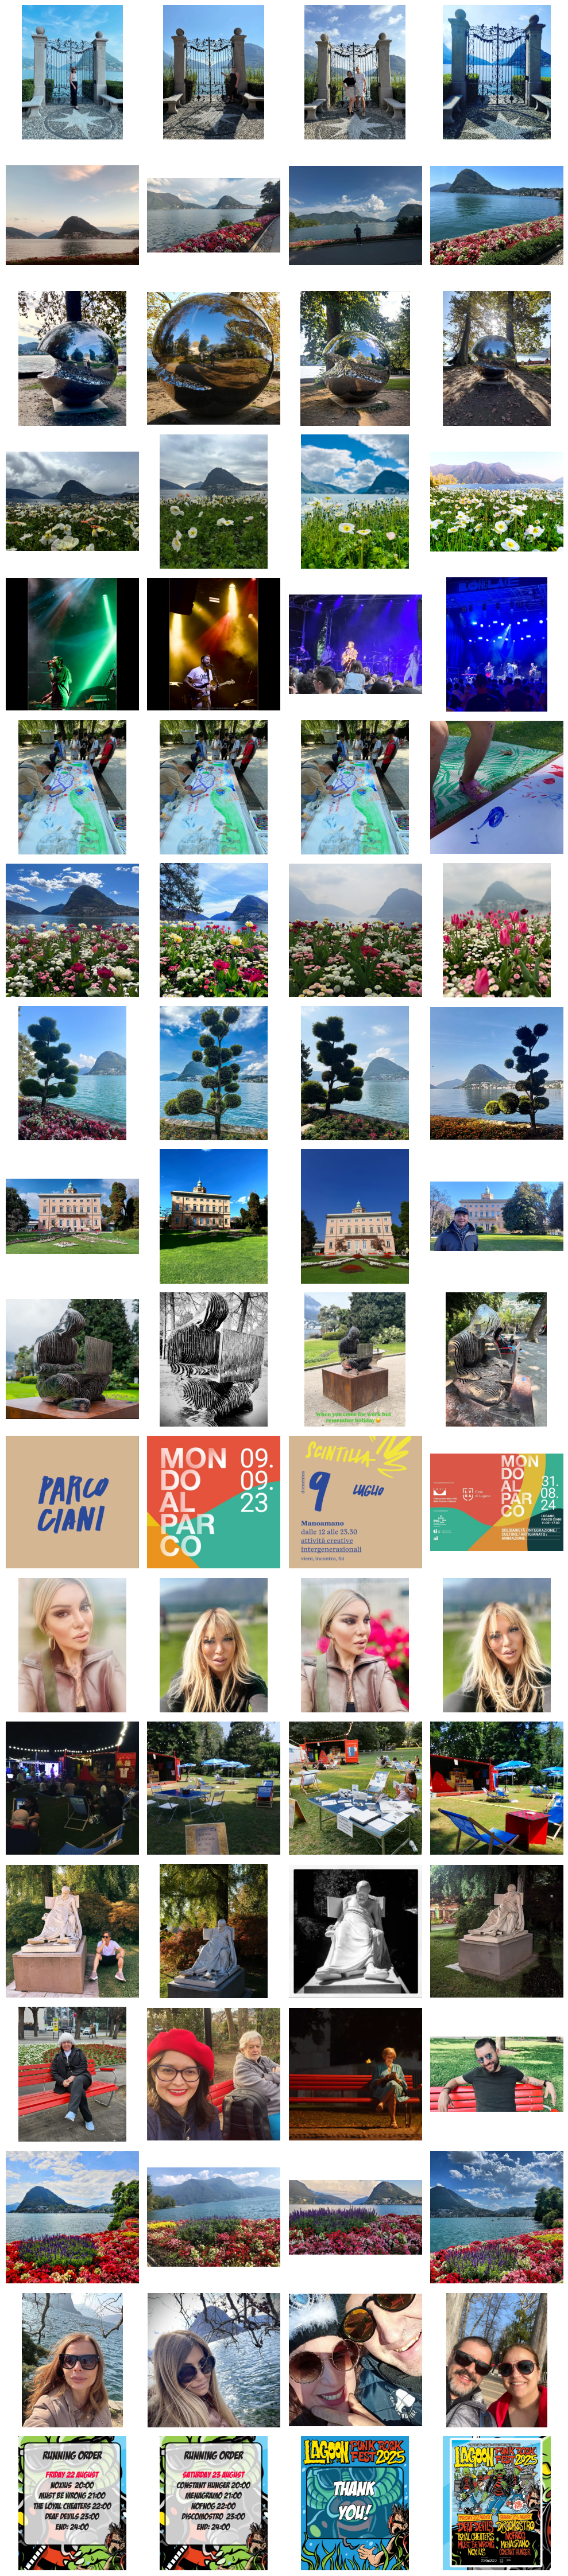

In [47]:
import matplotlib.pyplot as plt

def panoramica_cluster(cluster_ids, n_per_cluster=4):
    n_clusters_show = len(cluster_ids)
    fig, axes = plt.subplots(n_clusters_show, n_per_cluster, 
                              figsize=(n_per_cluster*2.5, n_clusters_show*2.5))
    if n_clusters_show == 1:
        axes = [axes]
    for row, cid in enumerate(cluster_ids):
        indici = np.where(labels == cid)[0]
        cluster_emb = embeddings_normalized[indici]
        centroide = cluster_emb.mean(axis=0)
        centroide = centroide / np.linalg.norm(centroide)
        distanze = np.linalg.norm(cluster_emb - centroide, axis=1)
        indici_ordinati = indici[np.argsort(distanze)][:n_per_cluster]
        for col, idx in enumerate(indici_ordinati):
            img = Image.open(valid_paths[idx])
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(f"C{cid}\n({len(indici)})", 
                                            rotation=0, ha='right', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

panoramica_cluster(cluster_ordinati, n_per_cluster=4)

In [48]:
import json
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
 
similarity_data = {}
 
for cid in set(labels):
    if cid == -1:
        continue
    
    indici = np.where(labels == cid)[0]
    if len(indici) < 2:
        continue
    
    cluster_emb = embeddings_normalized[indici]
    sim_matrix = cosine_similarity(cluster_emb)
    
    for i, idx in enumerate(indici):
        photo_name = Path(valid_paths[idx]).name
        
        similarities = []
        for j, other_idx in enumerate(indici):
            if i == j:
                continue
            other_name = Path(valid_paths[other_idx]).name
            score = float(sim_matrix[i, j])
            similarities.append({
                "photo": other_name,
                "score": round(score, 4)
            })
        
        similarities.sort(key=lambda x: -x["score"])
        similarity_data[photo_name] = similarities
 
output_path = OUTPUT_DIR / "photo_similarity.json"
with open(output_path, "w") as f:
    json.dump(similarity_data, f, indent=2)
 
print(f"✅ Similarity salvato: {output_path}")
print(f"   {len(similarity_data)} foto mappate")

✅ Similarity salvato: output/parcociani/photo_similarity.json
   443 foto mappate


In [33]:
from dotenv import load_dotenv
import os
from google import genai

load_dotenv(override=True)
api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    print("❌ API key non trovata nel .env")
else:
    print(f"✅ API key caricata ({len(api_key)} caratteri)")
    client = genai.Client(api_key=api_key)
    print("✅ Gemini configurato (nuova libreria)")

✅ API key caricata (39 caratteri)
✅ Gemini configurato (nuova libreria)


In [34]:
import json
import numpy as np
from pathlib import Path

# === COORDINATE PER OGNI LOCATION ===
# Aggiusta cliccando col destro su Google Maps → "Cosa c'è qui?"

LOCATIONS = {
    "parcociani": {
        "hotspot_coords": {
            7: {"lat": 46.00307, "lng": 8.95473, "spread_m": 6},    # Cancello iconico
            8: {"lat": 46.00257, "lng": 8.95458, "spread_m": 50},   # Monte San Salvatore vista
            3: {"lat": 46.00342, "lng": 8.95379, "spread_m": 4},    # Sfera riflettente
            5: {"lat": 46.00362, "lng": 8.95425, "spread_m": 25},   # Tulipani
            2: {"lat": 46.00388, "lng": 8.95501, "spread_m": 12},   # Villa Ciani
            9: {"lat": 46.00295, "lng": 8.95398, "spread_m": 6},    # Topiaria
            0: {"lat": 46.00408, "lng": 8.95460, "spread_m": 30},   # LongLake Festival
            4: {"lat": 46.00378, "lng": 8.95402, "spread_m": 20},   # Azalee
            1: {"lat": 46.00335, "lng": 8.95445, "spread_m": 15},   # Cervi luminosi
            6: {"lat": 46.00365, "lng": 8.95436, "spread_m": 25},   # Papaveri
        }
    },
    "montebre": {
        "hotspot_coords": {
            # IMPORTANTE: questi cluster_id devono corrispondere a quelli nel tuo hotspots.json di montebre
            # Le coordinate sotto sono stimate — aggiustale dopo
            # Se non conosci gli ID, esegui prima la cella e vedi l'errore, poi aggiusta
        }
    }
}

# === PRIMA: scopriamo quali cluster ha Monte Brè ===
montebre_hotspots_path = Path("output/montebre/hotspots.json")
if montebre_hotspots_path.exists():
    with open(montebre_hotspots_path) as f:
        mb_hotspots = json.load(f)
    print("=== CLUSTER MONTE BRÈ ===")
    for h in mb_hotspots:
        print(f"  C{h['cluster_id']} ({h['size']} foto): {h['label']}")
    print("\nCopia gli ID sopra e assegna coordinate nel dizionario LOCATIONS['montebre']")
    print("Per ora genero con coordinate stimate attorno alla vetta.\n")
    
    # Coordinate stimate attorno a Monte Brè
    # Vetta: 46.0073, 8.9873
    # Panoramica sud (verso lago): 46.0065, 8.9870
    # Funicolare arrivo: 46.0070, 8.9865
    base_lat = 46.0070
    base_lng = 8.9870
    
    for i, h in enumerate(mb_hotspots):
        cid = h["cluster_id"]
        # Distribuisci i cluster in un arco attorno alla vetta
        angle = (i / len(mb_hotspots)) * 2 * np.pi
        offset = 0.0003  # ~30m
        LOCATIONS["montebre"]["hotspot_coords"][cid] = {
            "lat": base_lat + np.sin(angle) * offset,
            "lng": base_lng + np.cos(angle) * offset,
            "spread_m": 20
        }

# === GENERA GEOJSON COMBINATO ===
M_TO_DEG_LAT = 1 / 111000
M_TO_DEG_LNG = 1 / (111000 * np.cos(np.radians(46.0)))

features = []
np.random.seed(42)

for location_name, location_data in LOCATIONS.items():
    hotspots_path = Path("output") / location_name / "hotspots.json"
    if not hotspots_path.exists():
        print(f"⚠️ {hotspots_path} non trovato, salto")
        continue
    
    with open(hotspots_path) as f:
        hotspots = json.load(f)
    
    coords_map = location_data["hotspot_coords"]
    
    for h in hotspots:
        cid = h["cluster_id"]
        if cid not in coords_map:
            print(f"  ⚠️ {location_name} C{cid} ({h['label']}): coordinate mancanti, salto")
            continue
        
        coords = coords_map[cid]
        n_photos = h["size"]
        spread = coords["spread_m"]
        
        for i in range(n_photos):
            offset_lat = np.random.normal(0, spread / 2) * M_TO_DEG_LAT
            offset_lng = np.random.normal(0, spread / 2) * M_TO_DEG_LNG
            
            photo = h["representative_photos"][i % len(h["representative_photos"])]
            
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Point",
                    "coordinates": [
                        coords["lng"] + offset_lng,
                        coords["lat"] + offset_lat
                    ]
                },
                "properties": {
                    "cluster_id": cid,
                    "location": location_name,
                    "label": h["label"],
                    "description": h["description"],
                    "photo_path": photo,
                    "cluster_size": n_photos
                }
            }
            features.append(feature)
    
    print(f"✅ {location_name}: {sum(h['size'] for h in hotspots if h['cluster_id'] in coords_map)} punti generati")

geojson = {
    "type": "FeatureCollection",
    "features": features
}

# Salva nella cartella output principale
output_path = Path("output/geo_data_all.geojson")
with open(output_path, "w") as f:
    json.dump(geojson, f, indent=2)

print(f"\n=== TOTALE: {len(features)} punti salvati in {output_path} ===")

=== CLUSTER MONTE BRÈ ===
  C23 (290 foto): View of Monte San Salvatore
  C20 (158 foto): Wrought-iron gate in Parco Ciani
  C24 (63 foto): Monte San Salvatore from Parco Ciani
  C15 (34 foto): Sfera sculpture by Helidon Xhixha
  C7 (18 foto): Live music performance
  C19 (18 foto): Poppies at Parco Ciani
  C3 (17 foto): Modified BMW E36 cars
  C1 (16 foto): Outdoor community painting workshop
  C18 (16 foto): Monte San Salvatore mountain view
  C4 (16 foto): BMW E36 front wheel profile
  C2 (16 foto): BMW E36 rear view
  C22 (15 foto): Cloud-pruned tree overlooking Lake Lugano
  C12 (13 foto): Villa Ciani in Lugano
  C16 (13 foto): Digital Nomad metal sculpture
  C5 (11 foto): Event posters for Parco Ciani
  C11 (10 foto): Monte San Salvatore above fog
  C10 (9 foto): Festival Info Point shipping container
  C9 (7 foto): Historic alleys of Gandria
  C0 (7 foto): Monte Brè Funicular railway
  C13 (7 foto): View of Monte Brè
  C8 (7 foto): Iconic red park benches
  C21 (6 foto): Parco C

In [35]:
def descrivi_cluster_gemini(cluster_id, n_foto=4):
    indici = np.where(labels == cluster_id)[0]
    cluster_emb = embeddings_normalized[indici]
    centroide = cluster_emb.mean(axis=0)
    centroide = centroide / np.linalg.norm(centroide)
    distanze = np.linalg.norm(cluster_emb - centroide, axis=1)
    indici_ordinati = indici[np.argsort(distanze)][:n_foto]
    
    images = [Image.open(valid_paths[idx]) for idx in indici_ordinati]
    
    prompt = """These photos were clustered together by an AI as visually similar tourist photos from Parco Ciani, a public park in Lugano, Switzerland.

Analyze them and identify the common subject — likely an iconic landmark or recurring view.

Respond with ONLY a valid JSON object (no markdown fences, no extra text):
{
  "label": "short label of 3-5 words in English",
  "description": "1-2 sentences describing what is depicted",
  "search_prompt": "a concise visual description suitable for an object detection model",
  "confidence": 0.0
}

confidence is a float 0-1 indicating how coherent the cluster is."""
    
    response = client.models.generate_content(
        model='gemini-3-flash-preview',
        contents=[prompt] + images
    )
    return response.text

# Test
cid_test = cluster_ordinati[0]
print(f"Test su Cluster {cid_test}...\n")
result = descrivi_cluster_gemini(cid_test, n_foto=4)
print(result)

Test su Cluster 8...

{
  "label": "San Lorenzo Cathedral Bell Tower",
  "description": "The prominent stone bell tower of the Cathedral of Saint Lawrence overlooking the city of Lugano, the lake, and the surrounding mountains.",
  "search_prompt": "tall stone bell tower with green dome and cross overlooking a lake and mountains",
  "confidence": 1.0
}


In [36]:
CLUSTER_VALIDI = list(cluster_ordinati)
print(f"Cluster da processare: {CLUSTER_VALIDI}")

Cluster da processare: [np.int64(8), np.int64(10), np.int64(11), np.int64(7), np.int64(3), np.int64(12), np.int64(1), np.int64(9), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(0)]


In [37]:
import re
import time

hotspots = []

for cid in CLUSTER_VALIDI:
    print(f"Processo Cluster {cid}...")
    try:
        raw_response = descrivi_cluster_gemini(cid, n_foto=4)
        cleaned = re.sub(r'```json\s*|\s*```', '', raw_response).strip()
        data = json.loads(cleaned)
        
        indici = np.where(labels == cid)[0]
        cluster_emb = embeddings_normalized[indici]
        centroide = cluster_emb.mean(axis=0)
        centroide = centroide / np.linalg.norm(centroide)
        distanze = np.linalg.norm(cluster_emb - centroide, axis=1)
        indici_ordinati = indici[np.argsort(distanze)]
        rappresentative = [str(valid_paths[idx]) for idx in indici_ordinati[:8]]
        
        hotspot = {
            "cluster_id": int(cid),
            "size": int(len(indici)),
            "label": data.get("label", ""),
            "description": data.get("description", ""),
            "search_prompt": data.get("search_prompt", ""),
            "confidence": float(data.get("confidence", 0)),
            "representative_photos": rappresentative
        }
        hotspots.append(hotspot)
        print(f"  ✓ {hotspot['label']} (conf: {hotspot['confidence']})")
        
        time.sleep(2)  # rate limit Gemini gratuito
        
    except json.JSONDecodeError as e:
        print(f"  ✗ Errore parsing JSON: {e}")
        print(f"  Raw: {raw_response[:300]}")
    except Exception as e:
        print(f"  ✗ Errore: {e}")

# Ordina per dimensione
hotspots.sort(key=lambda h: -h["size"])

# Salva il file finale
hotspots_path = OUTPUT_DIR / "hotspots.json"
with open(hotspots_path, "w") as f:
    json.dump(hotspots, f, indent=2, ensure_ascii=False)

print(f"\n=== HOTSPOT SALVATI in {hotspots_path} ===\n")
for h in hotspots:
    print(f"  C{h['cluster_id']:2d} ({h['size']:3d} foto): {h['label']:40s} [conf: {h['confidence']:.2f}]")

Processo Cluster 8...
  ✓ San Lorenzo Cathedral Bell Tower (conf: 1.0)
Processo Cluster 10...
  ✓ San Lorenzo Cathedral Interior (conf: 1.0)
Processo Cluster 11...
  ✓ Altar of San Rocco Church (conf: 1.0)
Processo Cluster 7...
  ✓ St. Lawrence Cathedral ceiling (conf: 1.0)
Processo Cluster 3...
  ✓ San Lorenzo Cathedral Interior (conf: 1.0)
Processo Cluster 12...
  ✓ Religious altarpieces in a church (conf: 0.95)
Processo Cluster 1...
  ✓ Cathedral Pipe Organ and Frescoes (conf: 1.0)
Processo Cluster 9...
  ✓ Villa Ciani architectural reliefs (conf: 0.95)
Processo Cluster 2...
  ✓ Catholic clergy in liturgical vestments (conf: 0.95)
Processo Cluster 4...
  ✓ Lugano Cathedral choir performances (conf: 1.0)
Processo Cluster 5...
  ✓ Frescoes of San Rocco Church (conf: 0.95)
Processo Cluster 6...
  ✓ Lugano Old Town Streets (conf: 0.95)
Processo Cluster 0...
  ✓ Saint Joseph mosaic fountain (conf: 1.0)

=== HOTSPOT SALVATI in output/cattedralesanlorenzo/hotspots.json ===

  C 8 (323 foto

In [39]:
# === Salva mapping completo cluster → foto ===
import json

# Usa solo i 3 cluster che ci servono
CLUSTER_EXPORT = [8,10,11,7,3,12,1,9,2,6,0]

cluster_photos = {}
for cid in CLUSTER_EXPORT:
    indici = np.where(labels == cid)[0]
    cluster_photos[str(cid)] = [str(valid_paths[i]) for i in indici]

# Salva
with open(OUTPUT_DIR / "cluster_photos.json", "w") as f:
    json.dump(cluster_photos, f, indent=2)

# Verifica
for cid, photos in cluster_photos.items():
    print(f"Cluster {cid}: {len(photos)} foto")
print(f"\nSalvato in {OUTPUT_DIR / 'cluster_photos.json'}")

Cluster 8: 323 foto
Cluster 10: 57 foto
Cluster 11: 54 foto
Cluster 7: 15 foto
Cluster 3: 13 foto
Cluster 12: 12 foto
Cluster 1: 9 foto
Cluster 9: 8 foto
Cluster 2: 8 foto
Cluster 6: 6 foto
Cluster 0: 6 foto

Salvato in output/cattedralesanlorenzo/cluster_photos.json


In [40]:
import json
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
 
similarity_data = {}
 
for cid in set(labels):
    if cid == -1:
        continue
    
    indici = np.where(labels == cid)[0]
    if len(indici) < 2:
        continue
    
    cluster_emb = embeddings_normalized[indici]
    sim_matrix = cosine_similarity(cluster_emb)
    
    for i, idx in enumerate(indici):
        photo_name = Path(valid_paths[idx]).name
        
        similarities = []
        for j, other_idx in enumerate(indici):
            if i == j:
                continue
            other_name = Path(valid_paths[other_idx]).name
            score = float(sim_matrix[i, j])
            similarities.append({
                "photo": other_name,
                "score": round(score, 4)
            })
        
        similarities.sort(key=lambda x: -x["score"])
        similarity_data[photo_name] = similarities
 
output_path = OUTPUT_DIR / "photo_similarity.json"
with open(output_path, "w") as f:
    json.dump(similarity_data, f, indent=2)
 
print(f"✅ Similarity salvato: {output_path}")
print(f"   {len(similarity_data)} foto mappate")

✅ Similarity salvato: output/cattedralesanlorenzo/photo_similarity.json
   524 foto mappate


In [41]:
import json
from pathlib import Path
 
merged = {}
output_root = Path("output")
 
for loc_dir in output_root.iterdir():
    if not loc_dir.is_dir():
        continue
    sim_path = loc_dir / "photo_similarity.json"
    if sim_path.exists():
        with open(sim_path) as f:
            data = json.load(f)
        merged.update(data)
        print(f"  ✅ {loc_dir.name}: {len(data)} foto")
 
output_path = output_root / "photo_similarity.json"
with open(output_path, "w") as f:
    json.dump(merged, f, indent=2)
 
print(f"\n=== MERGE COMPLETATO ===")
print(f"Totale: {len(merged)} foto in {output_path}")

  ✅ cattedralesanlorenzo: 524 foto

=== MERGE COMPLETATO ===
Totale: 524 foto in output/photo_similarity.json


In [49]:
import json
from pathlib import Path
 
merged = {}
output_root = Path("output")
 
for loc_dir in output_root.iterdir():
    if not loc_dir.is_dir():
        continue
    sim_path = loc_dir / "photo_similarity.json"
    if sim_path.exists():
        with open(sim_path) as f:
            data = json.load(f)
        merged.update(data)
        print(f"  ✅ {loc_dir.name}: {len(data)} foto")
 
output_path = output_root / "photo_similarity.json"
with open(output_path, "w") as f:
    json.dump(merged, f, indent=2)
 
print(f"\n=== MERGE COMPLETATO ===")
print(f"Totale: {len(merged)} foto in {output_path}")

  ✅ parcociani: 443 foto
  ✅ cattedralesanlorenzo: 524 foto

=== MERGE COMPLETATO ===
Totale: 967 foto in output/photo_similarity.json
